In [1]:
import json
import os

import fsspec
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from experiments.data_quality_scaling.llama.exp_data_quality_scaling import build_steps, MODELS, STEP_COUNTS, HQ_TOTAL_EFFECTIVE_STEPS
from marin.execution.executor import Executor

PREFIX = "gs://marin-us-central2"

/Users/rohith/research/marin/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-16 13:11:11,572	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Reconstruct executor graph and resolve output paths
all_steps = build_steps()
executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in all_steps:
    executor.compute_version(step, is_pseudo_dep=False)

print(f"{len(all_steps)} total steps ({len(all_steps)//2} phase1 + {len(all_steps)//2} phase2)")

24 total steps (12 phase1 + 12 phase2)


In [3]:
from experiments.data_quality_scaling.utils import read_eval_metrics, get_final_metrics

In [4]:
# Read metrics for all runs
# Steps alternate: phase1, phase2, phase1, phase2, ...
rows = []
for i in range(0, len(all_steps), 2):
    phase1_step = all_steps[i]
    phase2_step = all_steps[i + 1]

    # Parse run config from step name
    # Phase 1 name: checkpoints/dq-{model_name}-{hq_frac}-lr{lr}-wd{wd}
    # Phase 2 name: checkpoints/dq-phase2-{model_name}-{hq_frac}-lr{lr}-wd{wd}
    p1_name = phase1_step.name.split("checkpoints/dq-")[1]  # e.g. "30m-0.4267-lr3e+00-wd0.1"
    parts = p1_name.split("-")
    model_name = parts[0]  # e.g. "30m"
    hq_frac = float(parts[1])  # e.g. 0.4267

    # Infer num_steps and total tokens from hq_fraction
    hq_steps = HQ_TOTAL_EFFECTIVE_STEPS[0]  # 500
    num_steps = round(hq_steps / hq_frac)
    total_tokens = num_steps * 128 * 1024  # batch_size * seq_len

    p1_path = executor.output_paths[phase1_step]
    p2_path = executor.output_paths[phase2_step]

    try:
        p1_metrics = get_final_metrics(p1_path)
        p2_metrics = get_final_metrics(p2_path)
    except Exception as e:
        print(f"Failed to read metrics for {phase1_step.name}: {e}")
        continue

    rows.append({
        "model": model_name,
        "num_steps": num_steps,
        "total_tokens_M": total_tokens / 1e6,
        "hq_fraction": hq_frac,
        "phase1_eval_loss": p1_metrics.get("eval/loss"),
        "phase1_high_loss": p1_metrics.get("eval/high/loss"),
        "phase1_low_loss": p1_metrics.get("eval/low/loss"),
        "phase1_high_bpb": p1_metrics.get("eval/high/bpb"),
        "phase1_low_bpb": p1_metrics.get("eval/low/bpb"),
        "phase2_eval_loss": p2_metrics.get("eval/loss"),
        "phase2_high_loss": p2_metrics.get("eval/high/loss"),
        "phase2_high_bpb": p2_metrics.get("eval/high/bpb"),
        "phase1_step": p1_metrics.get("step"),
        "phase2_step": p2_metrics.get("step"),
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} runs")
df

/Users/rohith/research/marin/.venv/lib/python3.11/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Loaded 12 runs


,model,num_steps,total_tokens_M,hq_fraction,phase1_eval_loss,phase1_high_loss,phase1_low_loss,phase1_high_bpb,phase1_low_bpb,phase2_eval_loss,phase2_high_loss,phase2_high_bpb,phase1_step,phase2_step
0,30m,1172,153.616384,0.4266,4.989435,4.993895,4.984977,1.523829,1.586542,4.853163,4.853163,1.480882,1171,499
1,30m,2344,307.232768,0.2133,4.677543,4.742422,4.612663,1.447086,1.468053,4.607399,4.607399,1.405881,2343,499
2,30m,4686,614.203392,0.1067,4.552635,4.662970,4.442299,1.422845,1.413837,4.499447,4.499447,1.372941,4687,499
3,75m,1172,153.616384,0.4266,4.496561,4.481436,4.511685,1.367458,1.435919,4.351280,4.351280,1.327737,1171,499
4,75m,2344,307.232768,0.2133,4.217621,4.273662,4.161579,1.304068,1.324500,4.150831,4.150831,1.266579,2343,499
5,75m,4686,614.203392,0.1067,4.080050,4.183939,3.976162,1.276693,1.265491,4.043475,4.043475,1.233829,4687,499
6,150m,1172,153.616384,0.4266,4.535977,4.532197,4.539758,1.382951,1.444853,4.361683,4.361683,1.330915,1171,499
7,150m,2344,307.232768,0.2133,4.037630,4.093729,3.981531,1.249164,1.267201,3.975258,3.975258,1.213013,2343,499
8,150m,4686,614.203392,0.1067,3.865385,3.968504,3.762266,1.210949,1.197415,3.844747,3.844747,1.173180,4687,499
9,300m,1172,153.616384,0.4266,4.799277,4.819424,4.779129,1.470637,1.521036,4.622129,4.622129,1.410430,1171,499


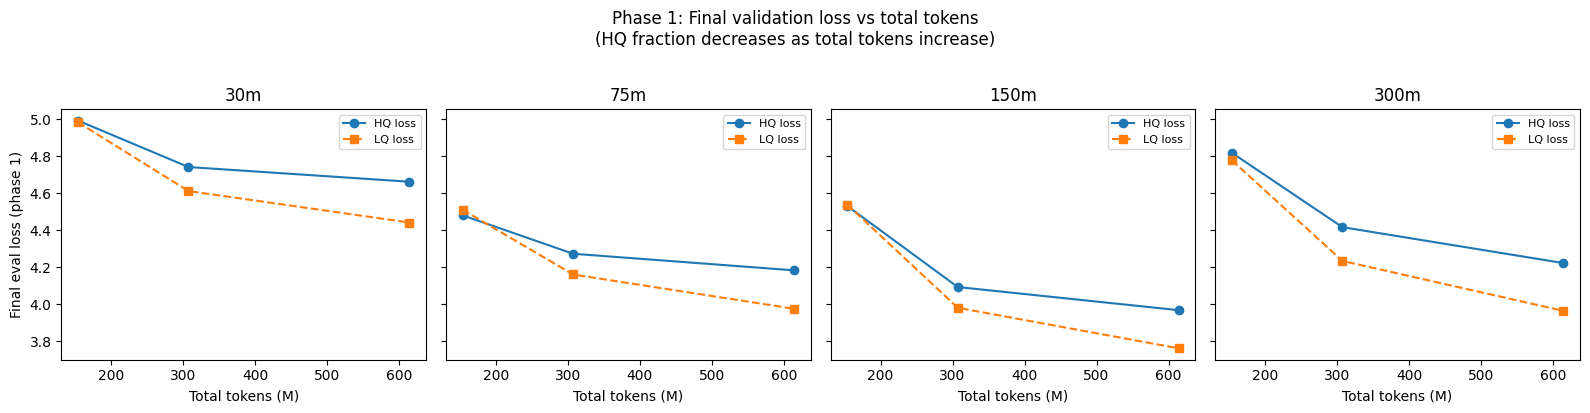

In [5]:
# Plot 1: Final HQ validation loss vs hq_fraction, faceted by model size
# x-axis: total tokens (or equivalently num_steps), since hq_fraction is just 500/num_steps
# Each subplot is a model size; each point shows the final high-quality eval loss

models_sorted = ["30m", "75m", "150m", "300m"]
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    subset = df[df["model"] == model].sort_values("total_tokens_M")
    ax.plot(subset["total_tokens_M"], subset["phase1_high_loss"], "o-", label="HQ loss")
    ax.plot(subset["total_tokens_M"], subset["phase1_low_loss"], "s--", label="LQ loss")
    ax.set_xlabel("Total tokens (M)")
    ax.set_title(f"{model}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final eval loss (phase 1)")
fig.suptitle("Phase 1: Final validation loss vs total tokens\n(HQ fraction decreases as total tokens increase)", y=1.02)
plt.tight_layout()
plt.show()

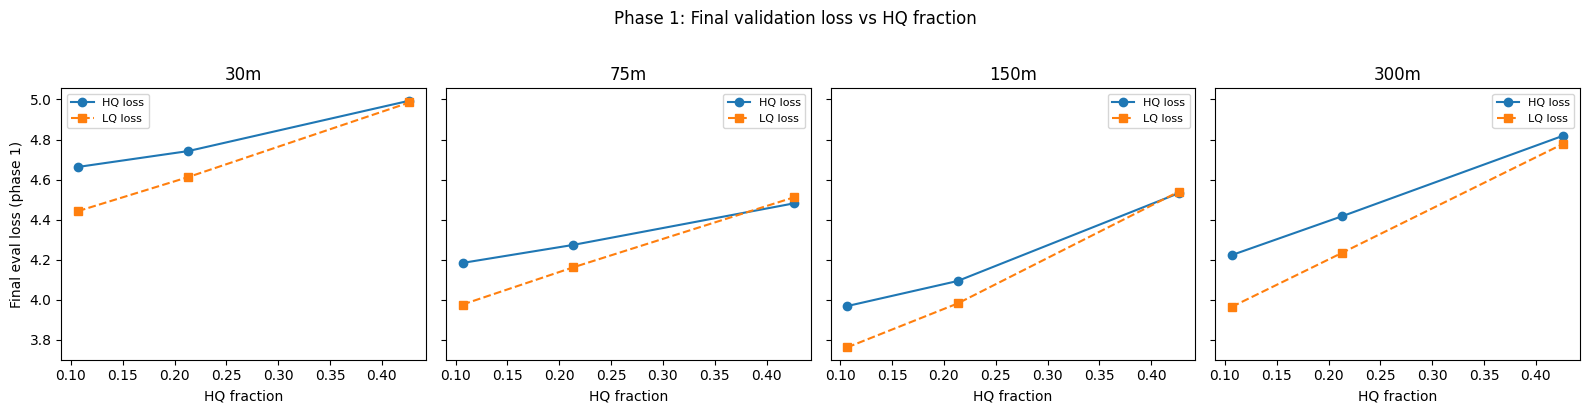

In [6]:
# Also plot with hq_fraction on x-axis
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    subset = df[df["model"] == model].sort_values("hq_fraction")
    ax.plot(subset["hq_fraction"], subset["phase1_high_loss"], "o-", label="HQ loss")
    ax.plot(subset["hq_fraction"], subset["phase1_low_loss"], "s--", label="LQ loss")
    ax.set_xlabel("HQ fraction")
    ax.set_title(f"{model}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final eval loss (phase 1)")
fig.suptitle("Phase 1: Final validation loss vs HQ fraction", y=1.02)
plt.tight_layout()
plt.show()

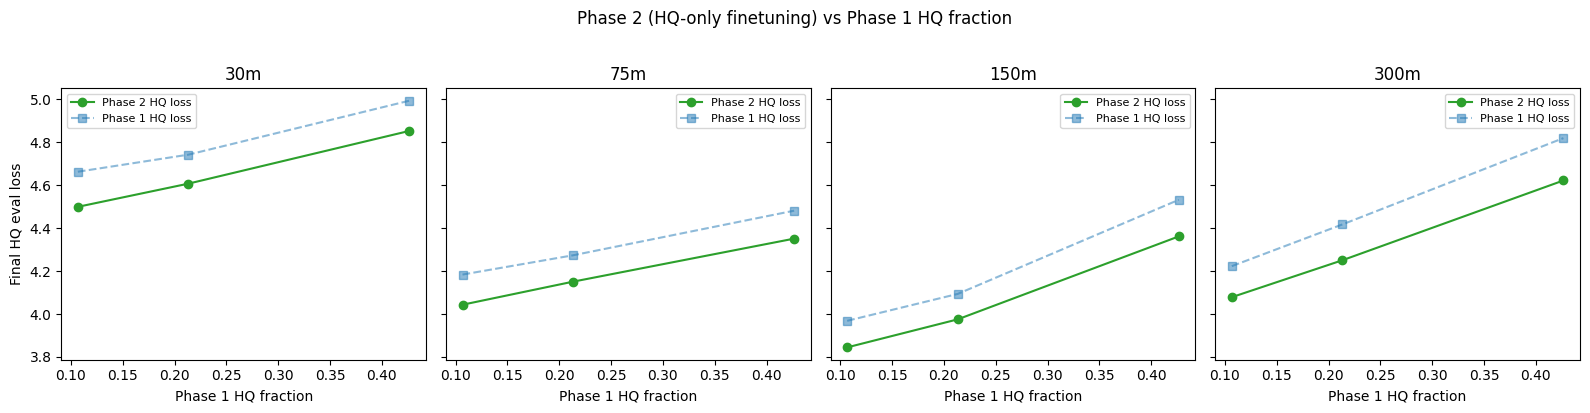

In [7]:
# Plot 2: Phase 2 final HQ loss vs phase 1 hq_fraction, faceted by model size
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    subset = df[df["model"] == model].sort_values("hq_fraction")
    ax.plot(subset["hq_fraction"], subset["phase2_high_loss"], "o-", color="tab:green", label="Phase 2 HQ loss")
    ax.plot(subset["hq_fraction"], subset["phase1_high_loss"], "s--", color="tab:blue", alpha=0.5, label="Phase 1 HQ loss")
    ax.set_xlabel("Phase 1 HQ fraction")
    ax.set_title(f"{model}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final HQ eval loss")
fig.suptitle("Phase 2 (HQ-only finetuning) vs Phase 1 HQ fraction", y=1.02)
plt.tight_layout()
plt.show()

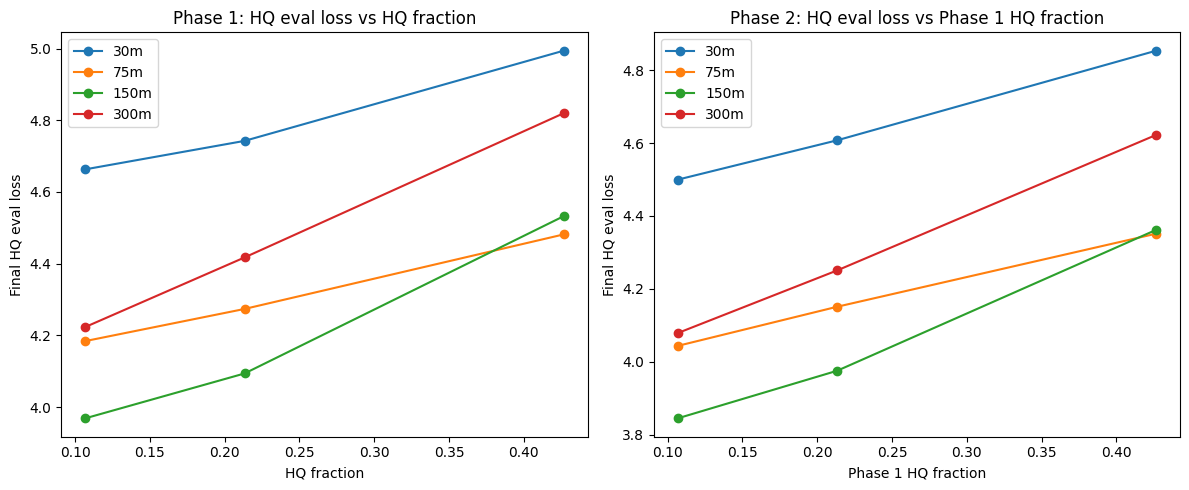

In [8]:
# Combined view: all model sizes on one plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Phase 1 HQ loss vs hq_fraction
for model in models_sorted:
    subset = df[df["model"] == model].sort_values("hq_fraction")
    axes[0].plot(subset["hq_fraction"], subset["phase1_high_loss"], "o-", label=model)
axes[0].set_xlabel("HQ fraction")
axes[0].set_ylabel("Final HQ eval loss")
axes[0].set_title("Phase 1: HQ eval loss vs HQ fraction")
axes[0].legend()

# Right: Phase 2 HQ loss vs hq_fraction
for model in models_sorted:
    subset = df[df["model"] == model].sort_values("hq_fraction")
    axes[1].plot(subset["hq_fraction"], subset["phase2_high_loss"], "o-", label=model)
axes[1].set_xlabel("Phase 1 HQ fraction")
axes[1].set_ylabel("Final HQ eval loss")
axes[1].set_title("Phase 2: HQ eval loss vs Phase 1 HQ fraction")
axes[1].legend()

plt.tight_layout()
plt.show()

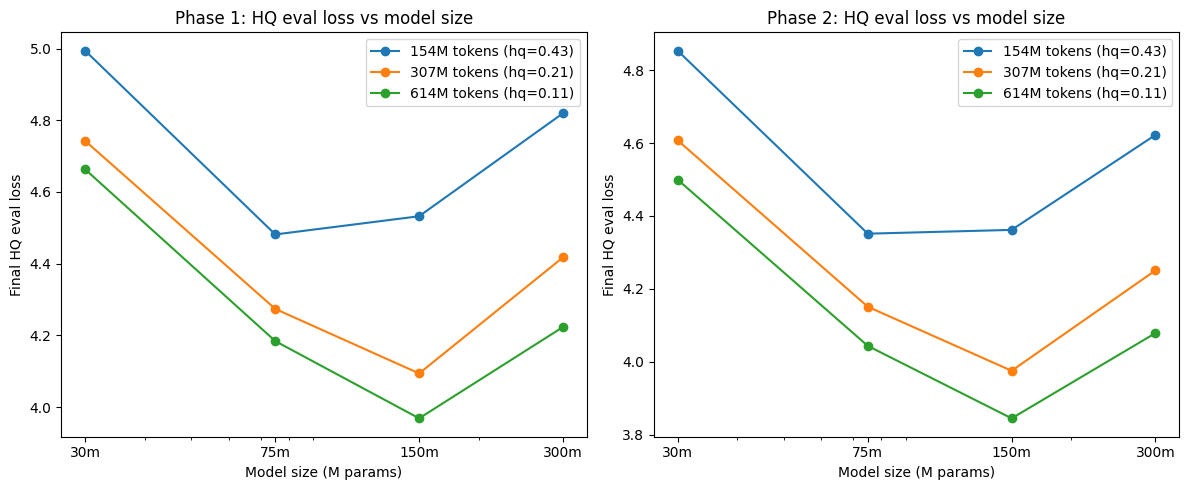

In [9]:
# Plot: Loss vs model size, one line per token budget
model_params = {"30m": 30, "75m": 75, "150m": 150, "300m": 300}
df["model_params"] = df["model"].map(model_params)

token_budgets = sorted(df["total_tokens_M"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Phase 1 HQ loss vs model size
for tokens in token_budgets:
    subset = df[df["total_tokens_M"] == tokens].sort_values("model_params")
    hq_frac = subset["hq_fraction"].iloc[0]
    axes[0].plot(subset["model_params"], subset["phase1_high_loss"], "o-",
                 label=f"{tokens:.0f}M tokens (hq={hq_frac:.2f})")
axes[0].set_xlabel("Model size (M params)")
axes[0].set_ylabel("Final HQ eval loss")
axes[0].set_title("Phase 1: HQ eval loss vs model size")
axes[0].set_xscale("log")
axes[0].set_xticks(list(model_params.values()))
axes[0].set_xticklabels(list(model_params.keys()))
axes[0].legend()

# Right: Phase 2 HQ loss vs model size
for tokens in token_budgets:
    subset = df[df["total_tokens_M"] == tokens].sort_values("model_params")
    hq_frac = subset["hq_fraction"].iloc[0]
    axes[1].plot(subset["model_params"], subset["phase2_high_loss"], "o-",
                 label=f"{tokens:.0f}M tokens (hq={hq_frac:.2f})")
axes[1].set_xlabel("Model size (M params)")
axes[1].set_ylabel("Final HQ eval loss")
axes[1].set_title("Phase 2: HQ eval loss vs model size")
axes[1].set_xscale("log")
axes[1].set_xticks(list(model_params.values()))
axes[1].set_xticklabels(list(model_params.keys()))
axes[1].legend()

plt.tight_layout()
plt.show()

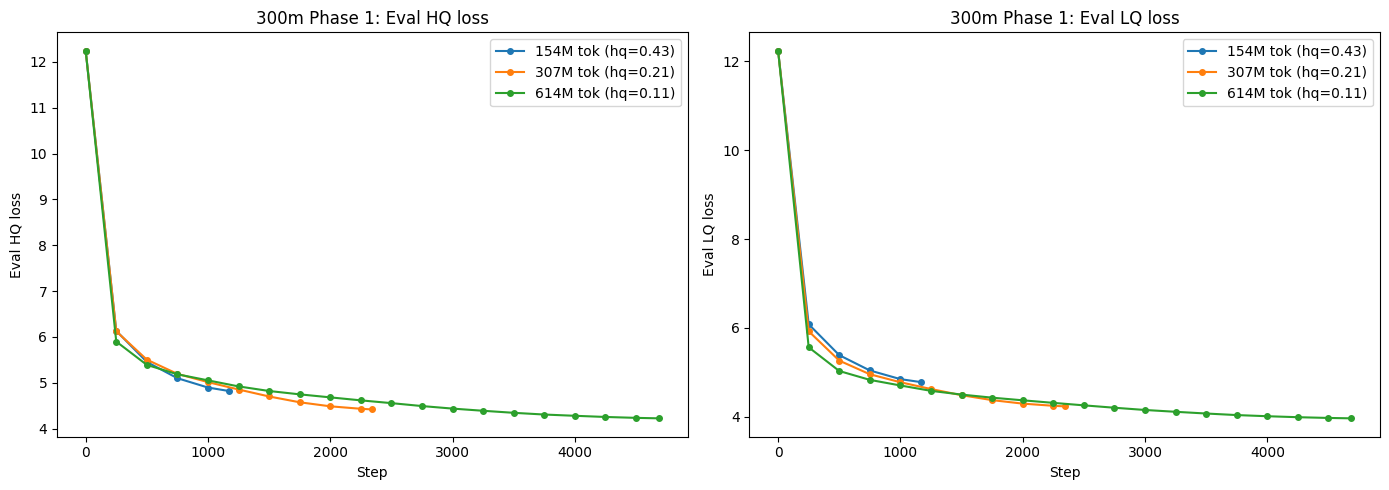

In [10]:
# Learning curves for the 300m model from GCS eval_metrics.jsonl
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(0, len(all_steps), 2):
    phase1_step = all_steps[i]
    p1_name = phase1_step.name.split("checkpoints/dq-")[1]
    parts = p1_name.split("-")
    model_name = parts[0]
    if model_name != "300m":
        continue

    hq_frac = float(parts[1])
    hq_steps = HQ_TOTAL_EFFECTIVE_STEPS[0]
    num_steps = round(hq_steps / hq_frac)
    total_tokens_M = num_steps * 128 * 1024 / 1e6
    label = f"{total_tokens_M:.0f}M tok (hq={hq_frac:.2f})"

    p1_path = executor.output_paths[phase1_step]
    records = read_eval_metrics(p1_path)

    steps = [r["step"] for r in records]
    high_loss = [r["eval/high/loss"] for r in records]
    low_loss = [r["eval/low/loss"] for r in records]

    axes[0].plot(steps, high_loss, "o-", label=label, markersize=4)
    axes[1].plot(steps, low_loss, "o-", label=label, markersize=4)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Eval HQ loss")
axes[0].set_title("300m Phase 1: Eval HQ loss")
axes[0].legend()

axes[1].set_xlabel("Step")
axes[1].set_ylabel("Eval LQ loss")
axes[1].set_title("300m Phase 1: Eval LQ loss")
axes[1].legend()

plt.tight_layout()
plt.show()

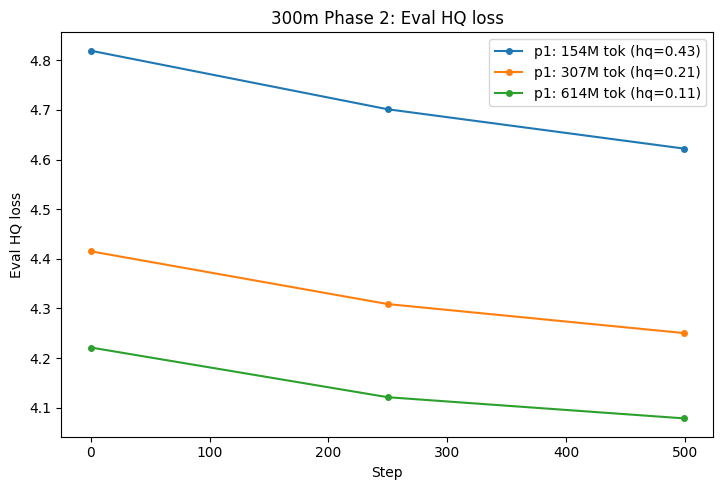

In [11]:
# Phase 2 learning curves for the 300m model from GCS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(0, len(all_steps), 2):
    phase1_step = all_steps[i]
    phase2_step = all_steps[i + 1]
    p1_name = phase1_step.name.split("checkpoints/dq-")[1]
    parts = p1_name.split("-")
    model_name = parts[0]
    if model_name != "300m":
        continue

    hq_frac = float(parts[1])
    hq_steps = HQ_TOTAL_EFFECTIVE_STEPS[0]
    num_steps = round(hq_steps / hq_frac)
    total_tokens_M = num_steps * 128 * 1024 / 1e6
    label = f"p1: {total_tokens_M:.0f}M tok (hq={hq_frac:.2f})"

    p2_path = executor.output_paths[phase2_step]
    records = read_eval_metrics(p2_path)

    steps = [r["step"] for r in records]
    high_loss = [r["eval/high/loss"] for r in records]

    axes[0].plot(steps, high_loss, "o-", label=label, markersize=4)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Eval HQ loss")
axes[0].set_title("300m Phase 2: Eval HQ loss")
axes[0].legend()

axes[1].set_visible(False)
plt.tight_layout()
plt.show()

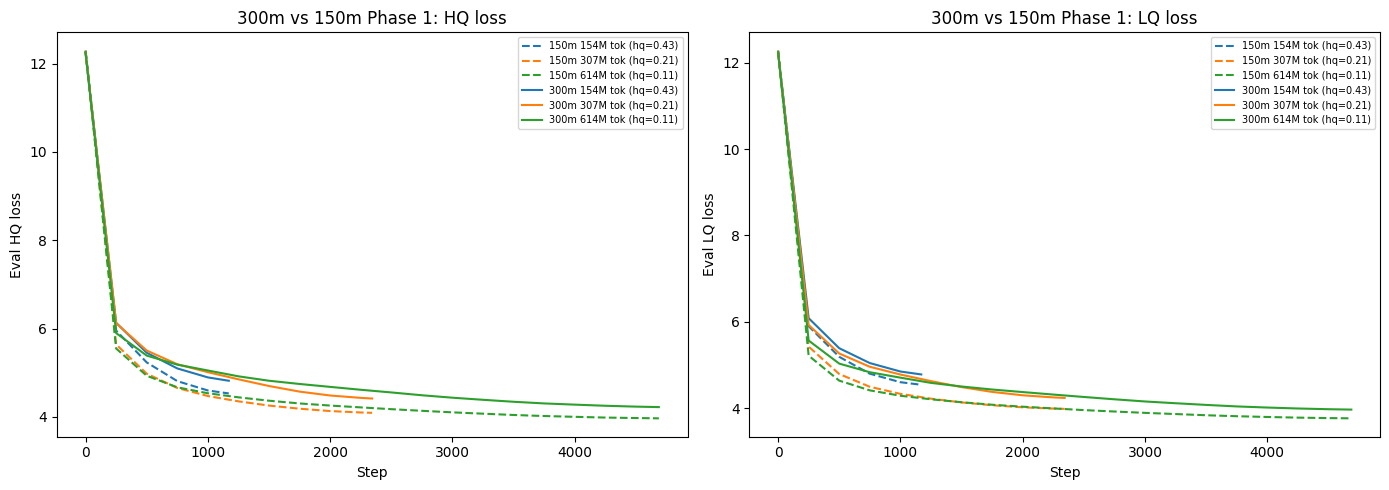

In [12]:
# Learning curves: 300m vs 150m comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_300m = {154: "tab:blue", 307: "tab:orange", 614: "tab:green"}
colors_150m = {154: "tab:blue", 307: "tab:orange", 614: "tab:green"}

for i in range(0, len(all_steps), 2):
    phase1_step = all_steps[i]
    p1_name = phase1_step.name.split("checkpoints/dq-")[1]
    parts = p1_name.split("-")
    model_name = parts[0]
    if model_name not in ("300m", "150m"):
        continue

    hq_frac = float(parts[1])
    hq_steps = HQ_TOTAL_EFFECTIVE_STEPS[0]
    num_steps = round(hq_steps / hq_frac)
    total_tokens_M = num_steps * 128 * 1024 / 1e6
    tok_key = round(total_tokens_M)

    p1_path = executor.output_paths[phase1_step]
    records = read_eval_metrics(p1_path)
    steps = [r["step"] for r in records]
    high_loss = [r["eval/high/loss"] for r in records]
    low_loss = [r["eval/low/loss"] for r in records]

    linestyle = "-" if model_name == "300m" else "--"
    label = f"{model_name} {total_tokens_M:.0f}M tok (hq={hq_frac:.2f})"
    color = colors_300m.get(tok_key, "tab:gray")

    axes[0].plot(steps, high_loss, linestyle, color=color, label=label, markersize=3)
    axes[1].plot(steps, low_loss, linestyle, color=color, label=label, markersize=3)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Eval HQ loss")
axes[0].set_title("300m vs 150m Phase 1: HQ loss")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("Step")
axes[1].set_ylabel("Eval LQ loss")
axes[1].set_title("300m vs 150m Phase 1: LQ loss")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [13]:
# --- LR sweep experiment (exp_data_quality_scaling_lr.py) ---
from experiments.data_quality_scaling.llama.exp_data_quality_scaling_lr import (
    build_steps as build_lr_steps,
    HQ_TOTAL_EFFECTIVE_STEPS as LR_HQ_STEPS,
    LEARNING_RATES,
)

lr_all_steps = build_lr_steps()
lr_executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in lr_all_steps:
    lr_executor.compute_version(step, is_pseudo_dep=False)

print(f"{len(lr_all_steps)} total LR sweep steps ({len(lr_all_steps)//2} phase1 + {len(lr_all_steps)//2} phase2)")

30 total LR sweep steps (15 phase1 + 15 phase2)


In [14]:
# Read LR sweep metrics for all 300m runs
import re

lr_rows = []
for i in range(0, len(lr_all_steps), 2):
    phase1_step = lr_all_steps[i]
    phase2_step = lr_all_steps[i + 1]

    # Name: checkpoints/dq-lr-300m-0.4266-lr1e-04-wd0.1
    m = re.search(r"dq-lr-(\w+)-([\d.]+)-lr([\d.e+\-]+)-wd([\d.]+)", phase1_step.name)
    model_name = m.group(1)
    hq_frac = float(m.group(2))
    lr_val = float(m.group(3))

    hq_steps = LR_HQ_STEPS[0]
    num_steps = round(hq_steps / hq_frac)
    total_tokens_M = num_steps * 128 * 1024 / 1e6

    p1_path = lr_executor.output_paths[phase1_step]
    p2_path = lr_executor.output_paths[phase2_step]

    try:
        p1_metrics = get_final_metrics(p1_path)
        p2_metrics = get_final_metrics(p2_path)
    except Exception as e:
        print(f"Failed to read metrics for {phase1_step.name}: {e}")
        continue

    lr_rows.append({
        "model": model_name,
        "num_steps": num_steps,
        "total_tokens_M": total_tokens_M,
        "hq_fraction": hq_frac,
        "lr": lr_val,
        "phase1_eval_loss": p1_metrics.get("eval/loss"),
        "phase1_high_loss": p1_metrics.get("eval/high/loss"),
        "phase1_low_loss": p1_metrics.get("eval/low/loss"),
        "phase1_high_bpb": p1_metrics.get("eval/high/bpb"),
        "phase1_low_bpb": p1_metrics.get("eval/low/bpb"),
        "phase2_eval_loss": p2_metrics.get("eval/loss"),
        "phase2_high_loss": p2_metrics.get("eval/high/loss"),
        "phase2_high_bpb": p2_metrics.get("eval/high/bpb"),
        "phase1_step": p1_metrics.get("step"),
        "phase2_step": p2_metrics.get("step"),
    })

df_lr = pd.DataFrame(lr_rows)
print(f"Loaded {len(df_lr)} LR sweep runs")
df_lr

Loaded 15 LR sweep runs


,model,num_steps,total_tokens_M,hq_fraction,lr,phase1_eval_loss,phase1_high_loss,phase1_low_loss,phase1_high_bpb,phase1_low_bpb,phase2_eval_loss,phase2_high_loss,phase2_high_bpb,phase1_step,phase2_step
0,300m,1172,153.616384,0.4266,0.0001,5.239894,5.273498,5.206290,1.609168,1.656974,5.166296,5.166296,1.576461,1171,499
1,300m,1172,153.616384,0.4266,0.0005,4.489346,4.500996,4.477696,1.373457,1.425102,4.363968,4.363968,1.331635,1171,499
2,300m,1172,153.616384,0.4266,0.0010,4.381526,4.381650,4.381403,1.337018,1.394458,4.223859,4.223859,1.288866,1171,499
3,300m,1172,153.616384,0.4266,0.0050,5.626304,5.663863,5.588745,1.728253,1.778695,5.440485,5.440485,1.660099,1171,499
4,300m,1172,153.616384,0.4266,0.0100,6.277741,6.299343,6.256140,1.922156,1.991099,6.101957,6.101957,1.861931,1171,499
5,300m,2344,307.232768,0.2133,0.0001,4.844252,4.966042,4.722462,1.515378,1.502997,4.866996,4.866996,1.485155,2343,499
6,300m,2344,307.232768,0.2133,0.0005,4.064521,4.142862,3.986180,1.264164,1.268678,4.039157,4.039157,1.232518,2343,499
7,300m,2344,307.232768,0.2133,0.0010,3.907812,3.971753,3.843871,1.211948,1.223389,3.865605,3.865605,1.179556,2343,499
8,300m,2344,307.232768,0.2133,0.0050,5.343493,5.469681,5.217305,1.669020,1.660483,5.287984,5.287984,1.613591,2343,499
9,300m,2344,307.232768,0.2133,0.0100,6.240275,6.336502,6.144048,1.933491,1.955424,6.084206,6.084206,1.856513,2343,499


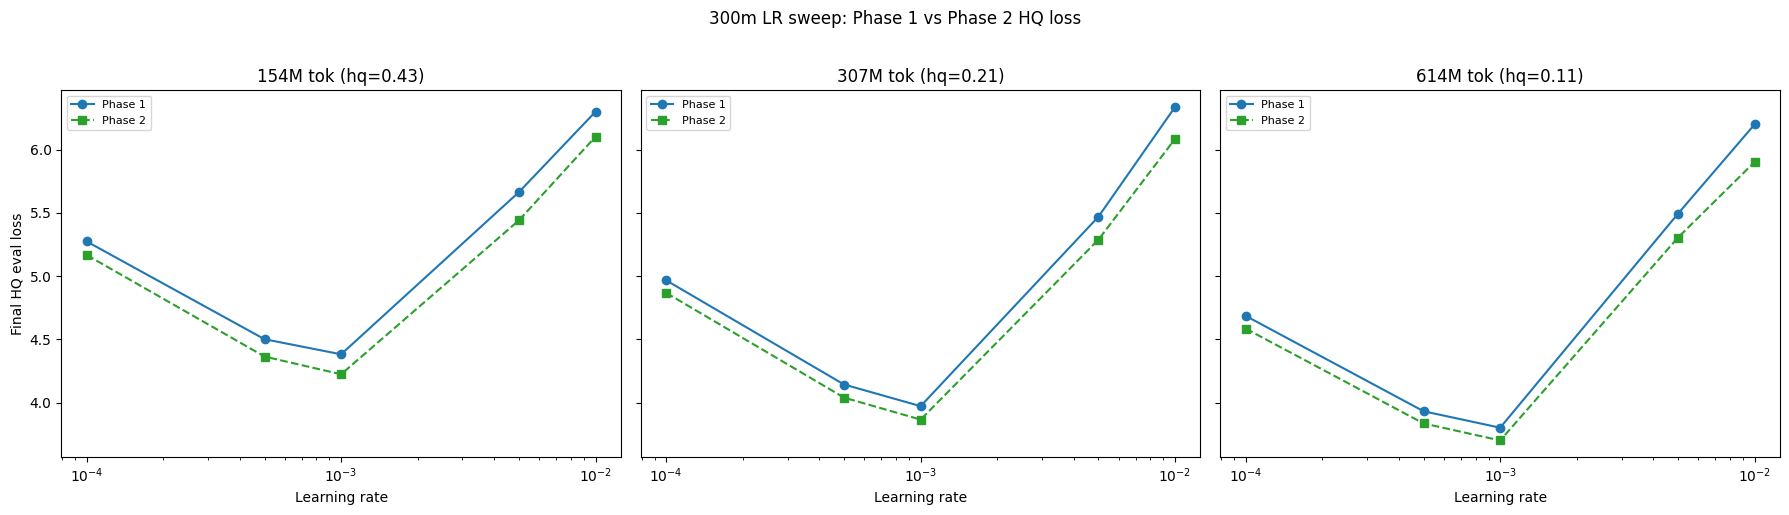

In [15]:
# LR sweep: Final HQ loss vs LR, phase 1 vs phase 2 overlaid
token_budgets_lr = sorted(df_lr["total_tokens_M"].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(token_budgets_lr), figsize=(6 * len(token_budgets_lr), 5), sharey=True)

for ax, tokens in zip(axes, token_budgets_lr):
    subset = df_lr[df_lr["total_tokens_M"] == tokens].sort_values("lr")
    hq_frac = subset["hq_fraction"].iloc[0]
    ax.plot(subset["lr"], subset["phase1_high_loss"], "o-", color="tab:blue", label="Phase 1")
    ax.plot(subset["lr"], subset["phase2_high_loss"], "s--", color="tab:green", label="Phase 2")
    ax.set_xscale("log")
    ax.set_xlabel("Learning rate")
    ax.set_title(f"{tokens:.0f}M tok (hq={hq_frac:.2f})")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final HQ eval loss")
fig.suptitle("300m LR sweep: Phase 1 vs Phase 2 HQ loss", y=1.02)
plt.tight_layout()
plt.show()

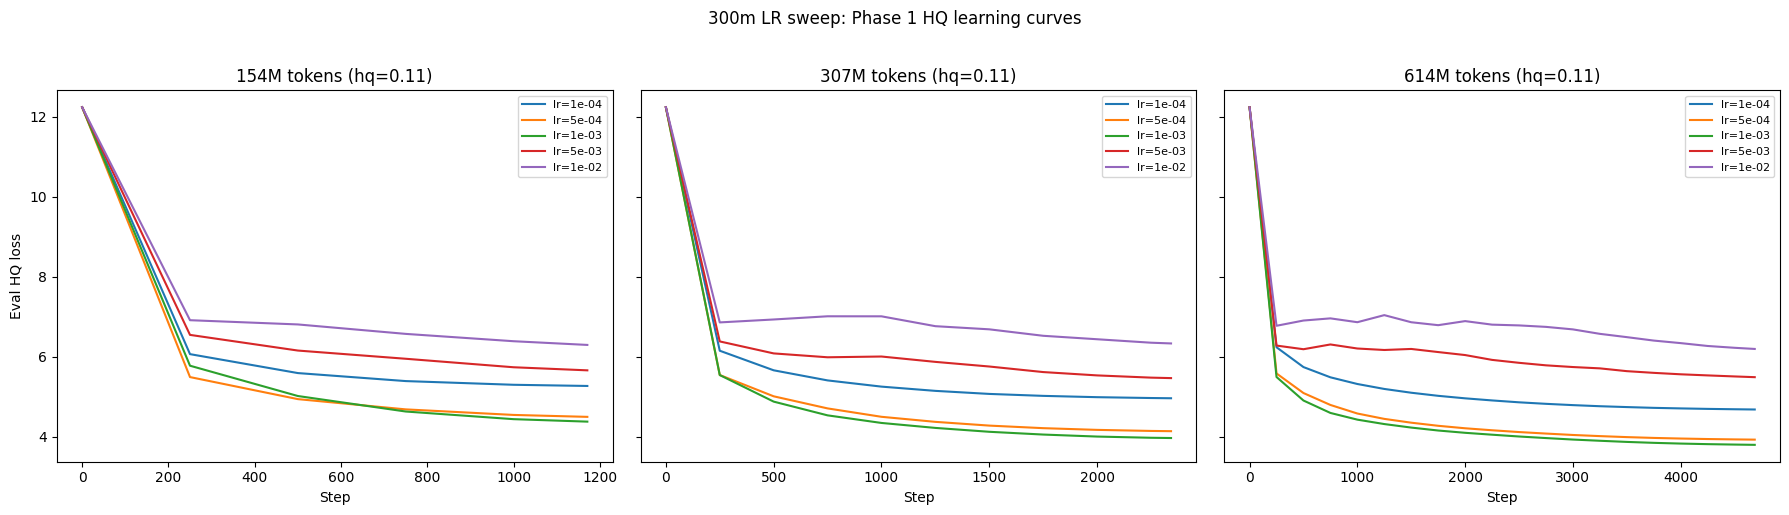

In [16]:
# LR sweep: Phase 1 learning curves for 300m, one subplot per token budget
fig, axes = plt.subplots(1, len(token_budgets_lr), figsize=(6 * len(token_budgets_lr), 5), sharey=True)

for ax, tokens in zip(axes, token_budgets_lr):
    for i in range(0, len(lr_all_steps), 2):
        phase1_step = lr_all_steps[i]
        m = re.search(r"dq-lr-(\w+)-([\d.]+)-lr([\d.e+\-]+)-wd([\d.]+)", phase1_step.name)
        hq_frac = float(m.group(2))
        lr_val = float(m.group(3))

        hq_steps = LR_HQ_STEPS[0]
        num_steps = round(hq_steps / hq_frac)
        total_tokens_M = num_steps * 128 * 1024 / 1e6

        if round(total_tokens_M) != round(tokens):
            continue

        p1_path = lr_executor.output_paths[phase1_step]
        try:
            records = read_eval_metrics(p1_path)
        except Exception:
            continue

        steps = [r["step"] for r in records]
        high_loss = [r["eval/high/loss"] for r in records]
        ax.plot(steps, high_loss, "-", label=f"lr={lr_val:.0e}", markersize=3)

    ax.set_xlabel("Step")
    ax.set_title(f"{tokens:.0f}M tokens (hq={hq_frac:.2f})")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Eval HQ loss")
fig.suptitle("300m LR sweep: Phase 1 HQ learning curves", y=1.02)
plt.tight_layout()
plt.show()

---
# Random (Word-Shuffled) Baseline Experiment
Results from `exp_data_quality_scaling_random.py`: models trained on word-shuffled Nemotron CC (noise baseline) with annealing to HQ.

In [19]:
from experiments.data_quality_scaling.llama.exp_data_quality_scaling_random import (
    build_steps as build_rand_steps,
    MODELS as RAND_MODELS,
    STEP_COUNTS as RAND_STEP_COUNTS,
    LR_TUNING_STEPS as RAND_LR_TUNING_STEPS,
    LEARNING_RATES as RAND_LEARNING_RATES,
)

rand_all_steps = build_rand_steps()
rand_executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in rand_all_steps:
    rand_executor.compute_version(step, is_pseudo_dep=False)

# default_train prefixes names with "checkpoints/"
rand_train_steps = [s for s in rand_all_steps if "dq-rand-train-" in s.name]
rand_tune_steps = [s for s in rand_all_steps if "dq-rand-tune-" in s.name]
rand_select_steps = [s for s in rand_all_steps if s.name.startswith("select-best-lr/")]

print(f"{len(rand_all_steps)} total steps: {len(rand_tune_steps)} tuning, {len(rand_select_steps)} select, {len(rand_train_steps)} training")

38 total steps: 20 tuning, 4 select, 12 training


In [20]:
# Read metrics for random baseline training runs
import re

rand_rows = []
for step in rand_train_steps:
    # Name: dq-rand-train-{model}-steps{num_steps}-wd{wd}
    m = re.search(r"dq-rand-train-(\w+)-steps(\d+)-wd([\d.]+)", step.name)
    if not m:
        print(f"Could not parse step name: {step.name}")
        continue
    model_name = m.group(1)
    num_steps = int(m.group(2))
    wd = float(m.group(3))
    total_tokens_M = num_steps * 128 * 1024 / 1e6

    out_path = rand_executor.output_paths[step]
    try:
        metrics = get_final_metrics(out_path)
    except Exception as e:
        print(f"Failed to read metrics for {step.name}: {e}")
        continue

    rand_rows.append({
        "model": model_name,
        "num_steps": num_steps,
        "total_tokens_M": total_tokens_M,
        "wd": wd,
        "eval_loss": metrics.get("eval/loss"),
        "high_loss": metrics.get("eval/high/loss"),
        "low_loss": metrics.get("eval/low/loss"),
        "high_bpb": metrics.get("eval/high/bpb"),
        "low_bpb": metrics.get("eval/low/bpb"),
        "final_step": metrics.get("step"),
    })

df_rand = pd.DataFrame(rand_rows)
print(f"Loaded {len(df_rand)} random baseline training runs")
df_rand

Loaded 12 random baseline training runs


,model,num_steps,total_tokens_M,wd,eval_loss,high_loss,low_loss,high_bpb,low_bpb,final_step
0,30m,100,13.107200,0.1,6.833625,5.306333,8.360918,1.619175,2.676642,599
1,30m,1172,153.616384,0.1,6.306157,5.006602,7.605712,1.527671,2.434864,1671
2,30m,2344,307.232768,0.1,6.248939,4.990324,7.507552,1.522689,2.403435,2843
3,75m,100,13.107200,0.1,6.708863,5.246264,8.171463,1.600842,2.615994,599
4,75m,1172,153.616384,0.1,6.171954,4.821661,7.522248,1.471244,2.408139,1671
5,75m,2344,307.232768,0.1,6.074242,4.739282,7.409202,1.446101,2.371947,2843
6,150m,100,13.107200,0.1,6.590901,4.986422,8.195380,1.521565,2.623651,599
7,150m,1172,153.616384,0.1,6.149878,4.872357,7.427399,1.486711,2.377777,1671
8,150m,2344,307.232768,0.1,6.038669,4.817065,7.260272,1.469825,2.324275,2843
9,300m,100,13.107200,0.1,6.570561,5.022578,8.118544,1.532601,2.599048,599


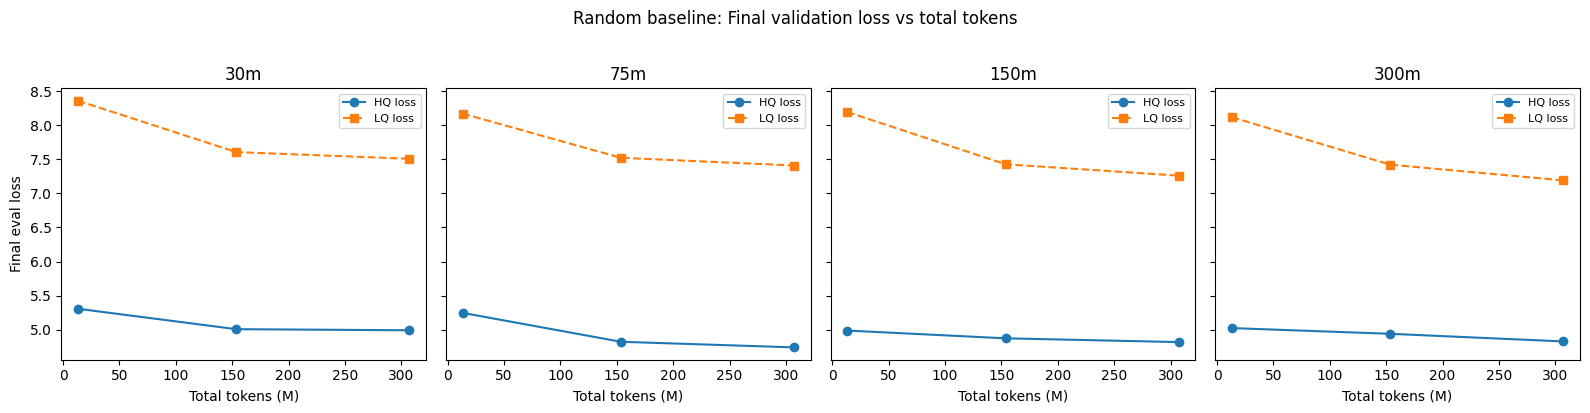

In [21]:
# Random baseline: Final HQ eval loss vs total tokens, faceted by model
models_sorted = ["30m", "75m", "150m", "300m"]
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    subset = df_rand[df_rand["model"] == model].sort_values("total_tokens_M")
    ax.plot(subset["total_tokens_M"], subset["high_loss"], "o-", label="HQ loss")
    ax.plot(subset["total_tokens_M"], subset["low_loss"], "s--", label="LQ loss")
    ax.set_xlabel("Total tokens (M)")
    ax.set_title(f"{model}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final eval loss")
fig.suptitle("Random baseline: Final validation loss vs total tokens", y=1.02)
plt.tight_layout()
plt.show()

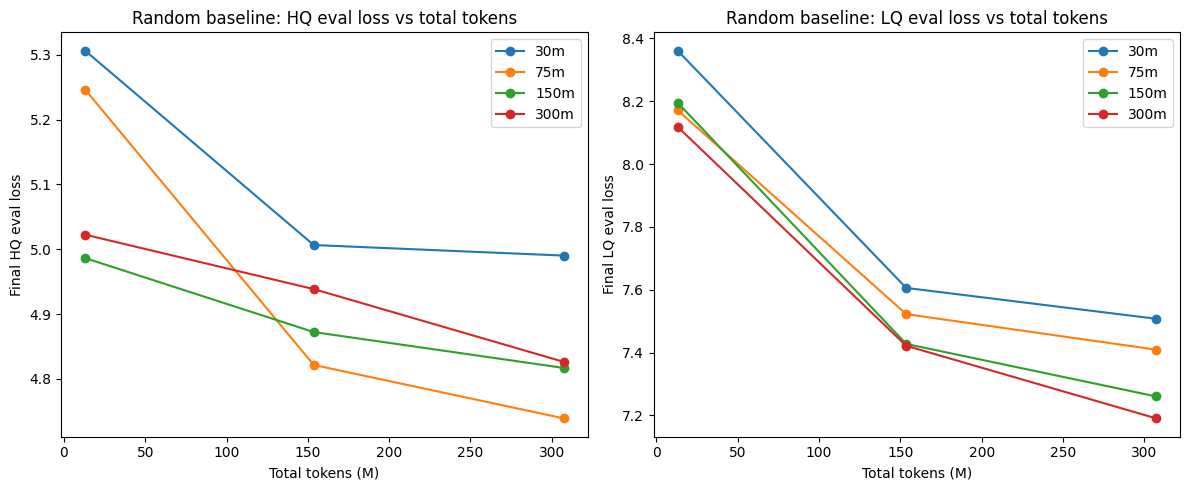

In [22]:
# Random baseline: Combined view — all model sizes on one plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for model in models_sorted:
    subset = df_rand[df_rand["model"] == model].sort_values("total_tokens_M")
    axes[0].plot(subset["total_tokens_M"], subset["high_loss"], "o-", label=model)
axes[0].set_xlabel("Total tokens (M)")
axes[0].set_ylabel("Final HQ eval loss")
axes[0].set_title("Random baseline: HQ eval loss vs total tokens")
axes[0].legend()

for model in models_sorted:
    subset = df_rand[df_rand["model"] == model].sort_values("total_tokens_M")
    axes[1].plot(subset["total_tokens_M"], subset["low_loss"], "o-", label=model)
axes[1].set_xlabel("Total tokens (M)")
axes[1].set_ylabel("Final LQ eval loss")
axes[1].set_title("Random baseline: LQ eval loss vs total tokens")
axes[1].legend()

plt.tight_layout()
plt.show()

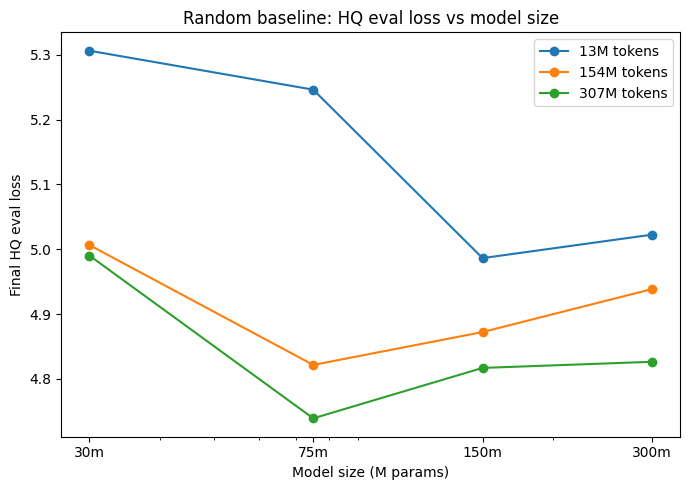

In [23]:
# Random baseline: Loss vs model size, one line per token budget
model_params = {"30m": 30, "75m": 75, "150m": 150, "300m": 300}
df_rand["model_params"] = df_rand["model"].map(model_params)

token_budgets_rand = sorted(df_rand["total_tokens_M"].unique())

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for tokens in token_budgets_rand:
    subset = df_rand[df_rand["total_tokens_M"] == tokens].sort_values("model_params")
    ax.plot(subset["model_params"], subset["high_loss"], "o-",
            label=f"{tokens:.0f}M tokens")

ax.set_xlabel("Model size (M params)")
ax.set_ylabel("Final HQ eval loss")
ax.set_title("Random baseline: HQ eval loss vs model size")
ax.set_xscale("log")
ax.set_xticks(list(model_params.values()))
ax.set_xticklabels(list(model_params.keys()))
ax.legend()
plt.tight_layout()
plt.show()

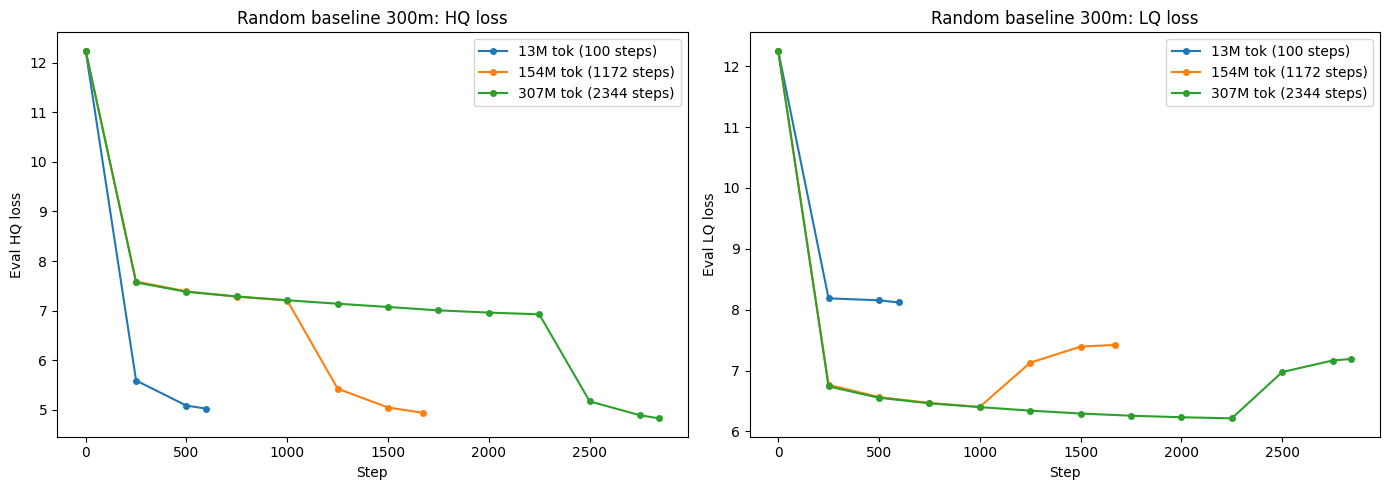

In [24]:
# Random baseline: Learning curves for 300m model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for step in rand_train_steps:
    m = re.search(r"dq-rand-train-(\w+)-steps(\d+)", step.name)
    model_name = m.group(1)
    if model_name != "300m":
        continue
    num_steps = int(m.group(2))
    total_tokens_M = num_steps * 128 * 1024 / 1e6
    label = f"{total_tokens_M:.0f}M tok ({num_steps} steps)"

    out_path = rand_executor.output_paths[step]
    try:
        records = read_eval_metrics(out_path)
    except Exception:
        continue

    steps = [r["step"] for r in records]
    high_loss = [r.get("eval/high/loss") for r in records]
    low_loss = [r.get("eval/low/loss") for r in records]

    axes[0].plot(steps, high_loss, "o-", label=label, markersize=4)
    axes[1].plot(steps, low_loss, "o-", label=label, markersize=4)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Eval HQ loss")
axes[0].set_title("Random baseline 300m: HQ loss")
axes[0].legend()

axes[1].set_xlabel("Step")
axes[1].set_ylabel("Eval LQ loss")
axes[1].set_title("Random baseline 300m: LQ loss")
axes[1].legend()

plt.tight_layout()
plt.show()

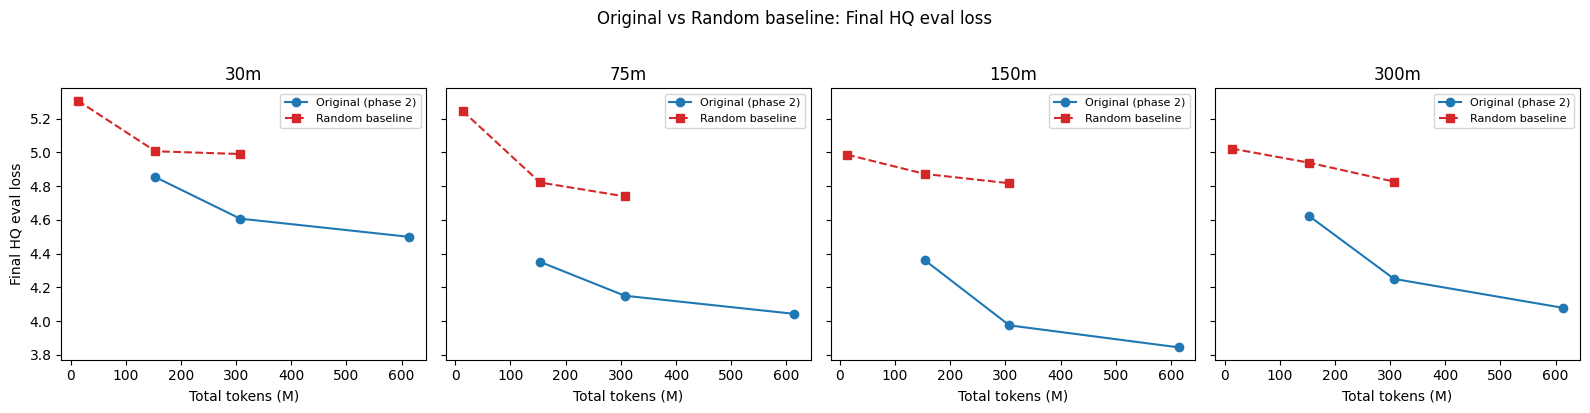

In [25]:
# Random vs Original: Compare HQ eval loss on same model/token budgets
# Overlay random baseline (dashed) with original experiment (solid)
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    # Original experiment
    orig_subset = df[df["model"] == model].sort_values("total_tokens_M")
    if len(orig_subset) > 0:
        ax.plot(orig_subset["total_tokens_M"], orig_subset["phase2_high_loss"], "o-",
                color="tab:blue", label="Original (phase 2)")

    # Random baseline
    rand_subset = df_rand[df_rand["model"] == model].sort_values("total_tokens_M")
    if len(rand_subset) > 0:
        ax.plot(rand_subset["total_tokens_M"], rand_subset["high_loss"], "s--",
                color="tab:red", label="Random baseline")

    ax.set_xlabel("Total tokens (M)")
    ax.set_title(f"{model}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Final HQ eval loss")
fig.suptitle("Original vs Random baseline: Final HQ eval loss", y=1.02)
plt.tight_layout()
plt.show()

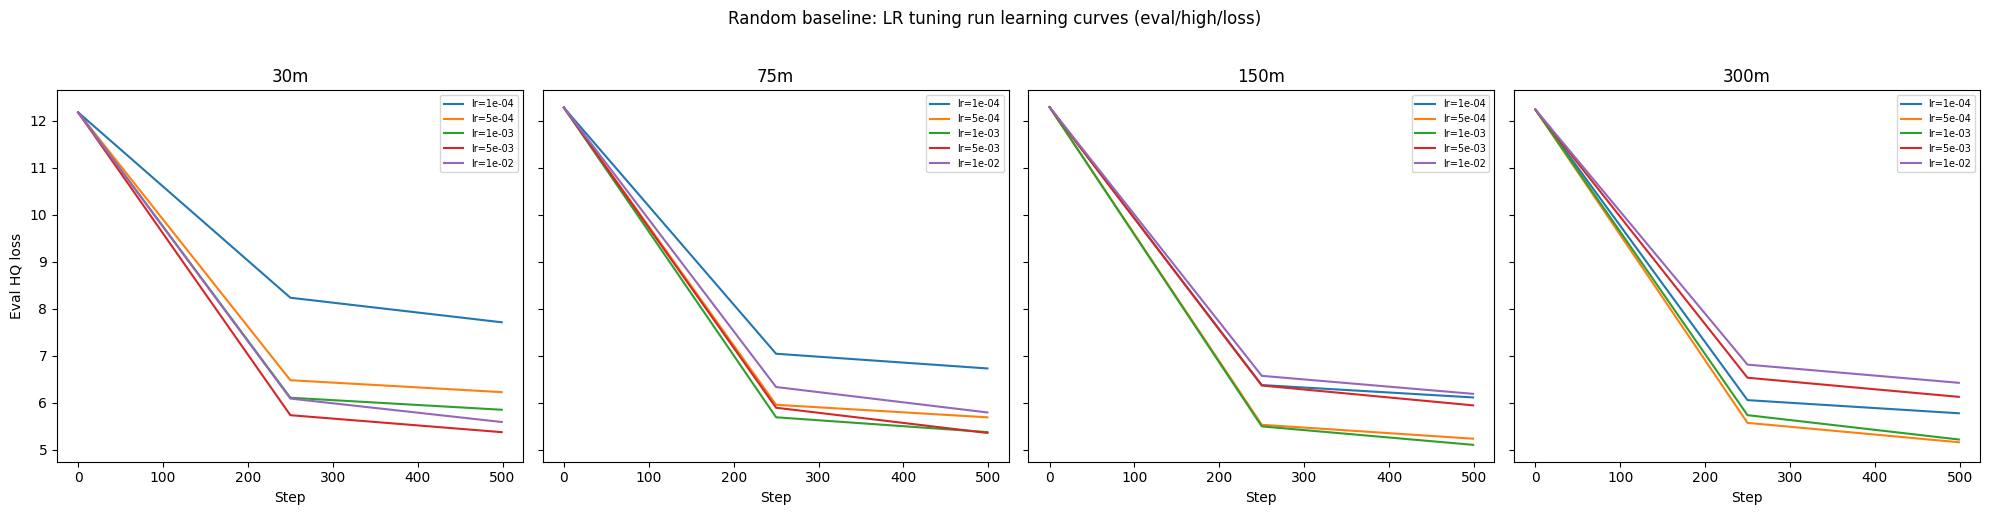

In [28]:
# Random baseline: LR tuning run learning curves, faceted by model
fig, axes = plt.subplots(1, len(models_sorted), figsize=(5 * len(models_sorted), 5), sharey=True)

for ax, model in zip(axes, models_sorted):
    for step in rand_tune_steps:
        m = re.search(r"dq-rand-tune-(\w+)-steps(\d+)-lr([\d.e+\-]+)-wd([\d.]+)", step.name)
        if not m:
            continue
        model_name = m.group(1)
        if model_name != model:
            continue
        lr_val = float(m.group(3))

        out_path = rand_executor.output_paths[step]
        try:
            records = read_eval_metrics(out_path)
        except Exception:
            continue

        steps_arr = [r["step"] for r in records]
        high_loss = [r.get("eval/high/loss") for r in records]
        ax.plot(steps_arr, high_loss, "-", label=f"lr={lr_val:.0e}", markersize=3)

    ax.set_xlabel("Step")
    ax.set_title(f"{model}")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Eval HQ loss")
fig.suptitle("Random baseline: LR tuning run learning curves (eval/high/loss)", y=1.02)
plt.tight_layout()
plt.show()

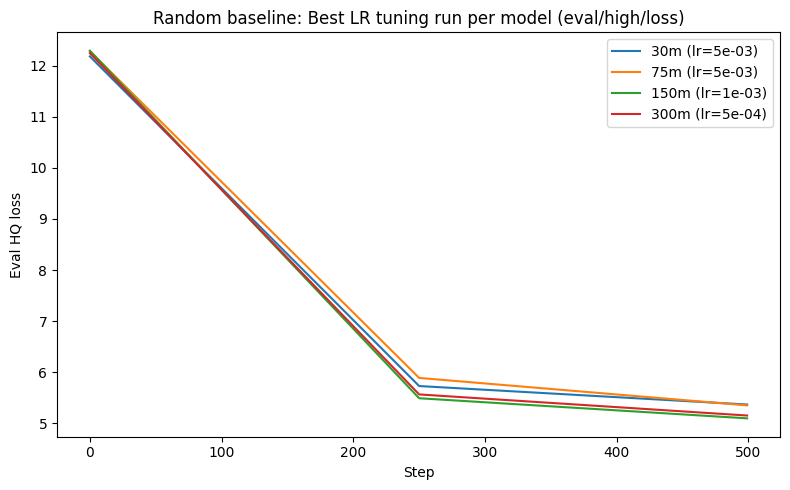

In [33]:
# Random baseline: Best LR tuning run per model overlaid on one plot
# For each model, pick the LR with the lowest final eval/high/loss
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for model in models_sorted:
    best_lr = None
    best_final_loss = float("inf")
    best_steps = None
    best_high_loss = None

    for step in rand_tune_steps:
        m = re.search(r"dq-rand-tune-(\w+)-steps(\d+)-lr([\d.e+\-]+)-wd([\d.]+)", step.name)
        if not m:
            continue
        model_name = m.group(1)
        if model_name != model:
            continue
        lr_val = float(m.group(3))

        out_path = rand_executor.output_paths[step]
        try:
            records = read_eval_metrics(out_path)
        except Exception:
            continue

        if not records:
            continue
        final_loss = records[-1].get("eval/high/loss", float("inf"))
        if final_loss < best_final_loss:
            best_final_loss = final_loss
            best_lr = lr_val
            best_steps = [r["step"] for r in records]
            best_high_loss = [r.get("eval/high/loss") for r in records]

    if best_steps is not None:
        ax.plot(best_steps, best_high_loss, "-", label=f"{model} (lr={best_lr:.0e})", markersize=3)

ax.set_xlabel("Step")
ax.set_ylabel("Eval HQ loss")
ax.set_title("Random baseline: Best LR tuning run per model (eval/high/loss)")
ax.legend()
plt.tight_layout()
plt.show()

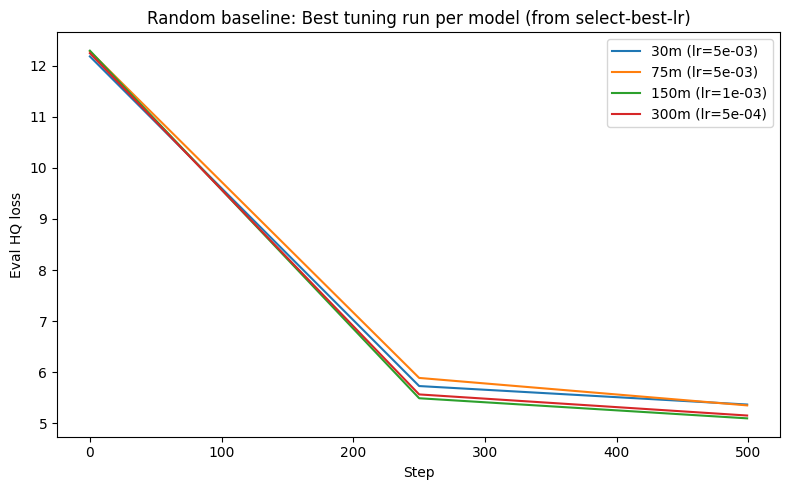

In [36]:
# Random baseline: Best tuning run per model using select-best-lr step output
from marin.execution import unwrap_versioned_value

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for select_step in rand_select_steps:
    select_path = rand_executor.output_paths[select_step]
    with fsspec.open(os.path.join(select_path, "best_lr.json"), "rt") as f:
        best = json.load(f)
    best_lr = best["best_lr"]

    model = select_step.name.split("dq-rand-")[-1]

    for step in rand_tune_steps:
        if model not in step.name:
            continue
        lr = unwrap_versioned_value(step.config.train_config.optimizer.learning_rate)
        if abs(lr - best_lr) / max(abs(best_lr), 1e-12) > 0.01:
            continue

        out_path = rand_executor.output_paths[step]
        records = read_eval_metrics(out_path)
        steps_arr = [r["step"] for r in records]
        high_loss = [r.get("eval/high/loss") for r in records]
        ax.plot(steps_arr, high_loss, "-", label=f"{model} (lr={best_lr:.0e})", markersize=3)
        break

ax.set_xlabel("Step")
ax.set_ylabel("Eval HQ loss")
ax.set_title("Random baseline: Best tuning run per model (from select-best-lr)")
ax.legend()
plt.tight_layout()
plt.show()

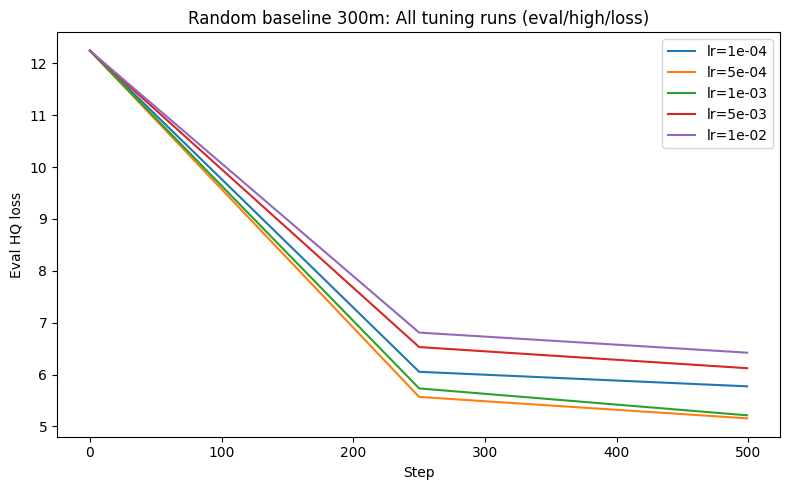

In [37]:
# Random baseline: All tuning runs for 300m, labeled with learning rate
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for step in rand_tune_steps:
    if "300m" not in step.name:
        continue
    lr = unwrap_versioned_value(step.config.train_config.optimizer.learning_rate)
    out_path = rand_executor.output_paths[step]
    records = read_eval_metrics(out_path)
    steps_arr = [r["step"] for r in records]
    high_loss = [r.get("eval/high/loss") for r in records]
    ax.plot(steps_arr, high_loss, "-", label=f"lr={lr:.0e}", markersize=3)

ax.set_xlabel("Step")
ax.set_ylabel("Eval HQ loss")
ax.set_title("Random baseline 300m: All tuning runs (eval/high/loss)")
ax.legend()
plt.tight_layout()
plt.show()